# ResNet18 per category

In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import accuracy_score
import statistics

### Dataset and DataLoader

In [2]:
dataset = 'dataset_224x224'

class MVTecDataset(Dataset):
    def __init__(self, dataset_path, category, transform=None, mode="train"):
        super().__init__()
        self.transform = transform
        self.data = []
        
        if mode == "train":
            good_path = os.path.join(dataset_path, category, "train", "good")
            for filename in os.listdir(good_path):
                self.data.append((os.path.join(good_path, filename), 0))
            
            test_path = os.path.join(dataset_path, category, "test")
            for subfolder in os.listdir(test_path):
                if subfolder != "good":
                    full_path = os.path.join(test_path, subfolder)
                    images = os.listdir(full_path)
                    train_split = int(len(images) * 0.7)
                    for filename in images[:train_split]:
                        self.data.append((os.path.join(full_path, filename), 1))
        
        elif mode == "test":
            test_path = os.path.join(dataset_path, category, "test")
            for subfolder in os.listdir(test_path):
                full_path = os.path.join(test_path, subfolder)
                images = os.listdir(full_path)
                if subfolder == "good":
                    for filename in images:
                        self.data.append((os.path.join(full_path, filename), 0))
                else:
                    test_split = int(len(images) * 0.7)
                    for filename in images[test_split:]:
                        self.data.append((os.path.join(full_path, filename), 1))
        
        np.random.shuffle(self.data)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        path, label = self.data[index]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

### Training per category

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

categories = sorted([c for c in os.listdir(dataset) if os.path.isdir(os.path.join(dataset, c))])
results = {}
num_epochs = 20
os.makedirs("models/per_category", exist_ok=True)

for category in categories:
    print(f"\n--- Training: {category} ---")
    train_dataset = MVTecDataset(dataset, category, transform=transform, mode="train")
    test_dataset = MVTecDataset(dataset, category, transform=transform, mode="test")
    
    labels = [l for _, l in train_dataset.data]
    if labels.count(1) == 0:
        print(f"No defect images for {category}")
        continue
    
    weights = torch.DoubleTensor([1.0/labels.count(0) if l == 0 else 1.0/labels.count(1) for l in labels])
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
    test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for images, batch_labels in train_dataloader:
            images = images.to(device)
            batch_labels = batch_labels.to(device)
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, batch_labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch [{epoch+1}/{num_epochs}] | Loss: {total_loss/len(train_dataloader):.4f}")
    
    model.eval()
    all_pred = []
    all_lab = []
    with torch.no_grad():
        for images, batch_labels in test_dataloader:
            images = images.to(device)
            output = model(images)
            predictions = output.argmax(axis=1)
            all_pred.extend(predictions.cpu().numpy())
            all_lab.extend(batch_labels.numpy())
    
    accuracy = accuracy_score(all_lab, all_pred) * 100
    results[category] = accuracy
    print(f"  Accuracy {category}: {accuracy:.2f}%")
    torch.save(model.state_dict(), f"models/per_category/{category}_model.pth")

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti

--- Training: bottle ---
  Epoch [1/20] | Loss: 0.4860
  Epoch [2/20] | Loss: 0.1166
  Epoch [3/20] | Loss: 0.0383
  Epoch [4/20] | Loss: 0.0137
  Epoch [5/20] | Loss: 0.0078
  Epoch [6/20] | Loss: 0.0037
  Epoch [7/20] | Loss: 0.0020
  Epoch [8/20] | Loss: 0.0017
  Epoch [9/20] | Loss: 0.0032
  Epoch [10/20] | Loss: 0.0011
  Epoch [11/20] | Loss: 0.0007
  Epoch [12/20] | Loss: 0.0009
  Epoch [13/20] | Loss: 0.0008
  Epoch [14/20] | Loss: 0.0005
  Epoch [15/20] | Loss: 0.0004
  Epoch [16/20] | Loss: 0.0003
  Epoch [17/20] | Loss: 0.0005
  Epoch [18/20] | Loss: 0.0003
  Epoch [19/20] | Loss: 0.0003
  Epoch [20/20] | Loss: 0.0002
  Accuracy bottle: 95.00%

--- Training: cable ---
  Epoch [1/20] | Loss: 0.4425
  Epoch [2/20] | Loss: 0.1707
  Epoch [3/20] | Loss: 0.0640
  Epoch [4/20] | Loss: 0.0222
  Epoch [5/20] | Loss: 0.0129
  Epoch [6/20] | Loss: 0.0202
  Epoch [7/20] | Loss: 0.0030
  Epoch [8/20] | Loss: 0.0035
  Epoch [9/20] | Loss: 0.00

### Results

Category        | Accuracy
------------------------------
bottle          | 95.00%
cable           | 87.50%
capsule         | 78.95%
carpet          | 56.90%
grid            | 82.93%
hazelnut        | 100.00%
leather         | 48.39%
metal_nut       | 88.24%
pill            | 70.83%
screw           | 86.08%
tile            | 93.44%
toothbrush      | 66.67%
transistor      | 90.28%
wood            | 82.05%
zipper          | 92.96%
------------------------------
Mean accuracy   | 81.35%
Median          | 86.08%


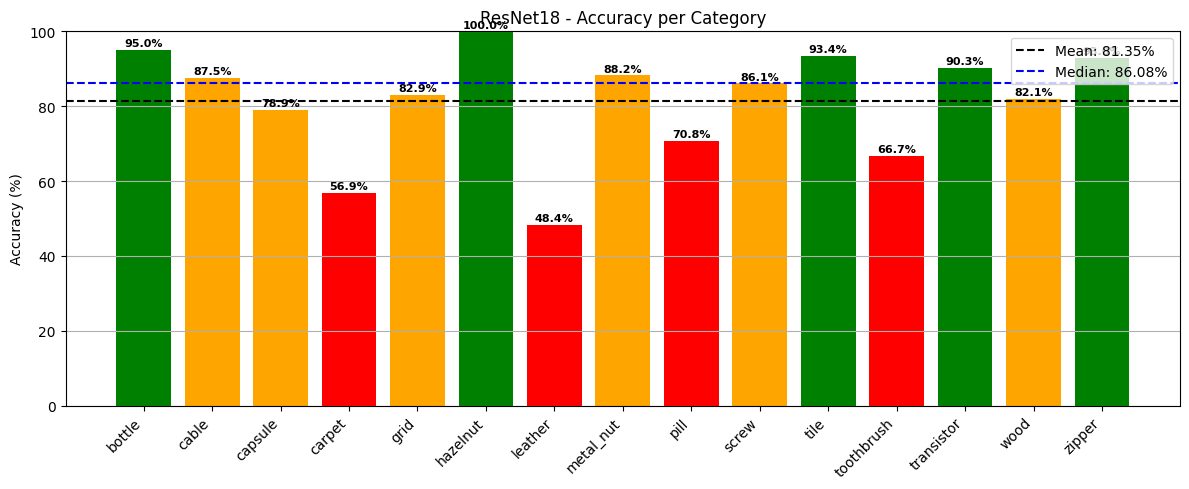

In [4]:
categories_list = list(results.keys())
accuracies_list = list(results.values())
mean_accuracy = np.mean(accuracies_list)
median_accuracy = statistics.median(accuracies_list)

print(f"{'Category':15} | {'Accuracy':8}")
print("-" * 30)
for cat, acc in results.items():
    print(f"{cat:15} | {acc:.2f}%")
print("-" * 30)
print(f"{'Mean accuracy':15} | {mean_accuracy:.2f}%")
print(f"{'Median':15} | {median_accuracy:.2f}%")

plt.figure(figsize=(12, 5))
colors = ['green' if t >= 90 else 'orange' if t >= 75 else 'red' for t in accuracies_list]
plt.bar(categories_list, accuracies_list, color=colors)
plt.axhline(mean_accuracy, color='black', linestyle='--', label=f'Mean: {mean_accuracy:.2f}%')
plt.axhline(median_accuracy, color='blue', linestyle='--', label=f'Median: {median_accuracy:.2f}%')
plt.xticks(rotation=45, ha='right')
plt.title('ResNet18 - Accuracy per Category')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, v in enumerate(accuracies_list):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()